In [2]:
import os
import glob
import requests
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from openpyxl import load_workbook
from scipy.spatial.distance import cdist 

# Make sure GOC is bi-directional.

In [ ]:
humanMouseRecipricol = pd.read_csv("/Users/andrewhsu/Projects/McNair/data/humanMouseReciprical.txt", sep="\t").rename(columns={"Gene stable ID": "MouseID", "Human gene stable ID": "HumanID"})

In [ ]:
orthologTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioType.parquet")

In [ ]:
orthologTableHumanGOC = orthologTable.merge(humanMouseRecipricol, left_on=["Gene stable ID", "Mouse gene stable ID"], right_on=["HumanID", "MouseID"], how="left").drop(columns=["MouseID", "HumanID"])
orthologTableHumanGOC.insert(3, "Human Gene-order conservation score", orthologTableHumanGOC.pop("Human Gene-order conservation score"))

# Identifying Duplicated Species

In [ ]:
orthoDist = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDist.parquet")
display(orthoDist)

In [ ]:
# Identifies the number of mouse genes associated with each human gene.
groupedHumanGene = orthoDist.groupby("Gene stable ID")["Mouse gene stable ID"].apply(list).reset_index(name="Mouse gene stable ID")

# Adds in the homology type to the dataframe.
groupedHumanGene = groupedHumanGene.merge(orthoDist.loc[:, ["Gene stable ID", "Mouse homology type"]])

# Identifies the human genes that have more than one mouse gene associated with them.
groupedHumanGene["Num Mouse Dupes"] = groupedHumanGene["Mouse gene stable ID"].apply(len)

# Creates a new column that identifies which one-to-many gene experienced a duplication event in humans. 
groupedHumanGene["Duplicated Species"] = np.where((groupedHumanGene["Gene stable ID"].isin(groupedHumanGene[groupedHumanGene["Num Mouse Dupes"] > 1]["Gene stable ID"])) & (groupedHumanGene["Mouse homology type"] == "ortholog_one2many"), "Mouse", "NA")

In [ ]:
groupedHumanGene

In [ ]:
# Transfers the information above to the orthologTableDist dataframe.
orthoDistHumanDup = orthoDist.merge(groupedHumanGene.loc[:, ["Gene stable ID", "Duplicated Species", "Num Mouse Dupes"]], left_on="Gene stable ID", right_on="Gene stable ID", how="outer")

In [ ]:
# Same steps as three cells above, but for mouse genes.
groupedMouseGene = orthoDist.groupby("Mouse gene stable ID")["Gene stable ID"].apply(list).reset_index(name="Gene stable ID")
groupedMouseGene = groupedMouseGene.merge(orthoDist.loc[:, ["Mouse gene stable ID", "Mouse homology type"]])
groupedMouseGene["Num Human Dupes"] = groupedMouseGene["Gene stable ID"].apply(len)
groupedMouseGene["Duplicated Species"] = np.where((groupedMouseGene["Mouse gene stable ID"].isin(groupedMouseGene[groupedMouseGene["Num Human Dupes"] > 1]["Mouse gene stable ID"])) & (groupedMouseGene["Mouse homology type"] == "ortholog_one2many"), "Human", "NA")

In [ ]:
groupedMouseGene[groupedMouseGene["Mouse gene stable ID"] == "ENSMUSG00000030945"]

In [ ]:
groupedMouseGene

In [ ]:
# Transfers the information above to the orthologDistTable dataframe.
orthoDistHumanMouseDup = orthoDistHumanDup.merge(groupedMouseGene.loc[:, ["Mouse gene stable ID", "Duplicated Species", "Num Human Dupes"]], on="Mouse gene stable ID", how="outer")

# Because there are two separate "Duplicated Species" columns, I am going to combine their information into one.
# If the human "Duplicated Species" column is "NA" then we use the mouse "Duplicated Species" column. It will either be "Mouse" or stay "NA."
orthoDistHumanMouseDup["Duplicated Species"] = np.where(orthoDistHumanMouseDup["Duplicated Species_x"] == "NA", orthoDistHumanMouseDup["Duplicated Species_y"], orthoDistHumanMouseDup["Duplicated Species_x"])

# Drop the two separate "Duplicated Species" columns.
orthoDistHumanMouseDup = orthoDistHumanMouseDup.loc[:, ~orthoDistHumanMouseDup.columns.isin(["Duplicated Species_x", "Duplicated Species_y"])].drop_duplicates()
display(orthoDistHumanMouseDup)

In [ ]:
orthoDistHumanMouseDup.columns[-1:]

In [ ]:
newColOrder = list(orthoDistHumanMouseDup.columns[:-3]) + list(orthoDistHumanMouseDup.columns[-2:-1]) + list(orthoDistHumanMouseDup.columns[-3:-2]) + list(orthoDistHumanMouseDup.columns[-1:])
orthoDistHumanMouseDup = orthoDistHumanMouseDup.loc[:, newColOrder]

In [ ]:
orthoDistHumanMouseDup.to_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupe.csv", index=False)
orthoDistHumanMouseDup.to_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupe.parquet", index=False)

In [ ]:
gtexEP = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/gtexExpressionProfile.parquet")
emtabEP = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/emtabExpressionProfile.parquet")

In [ ]:
gtexEP

In [ ]:
emtabEP

In [ ]:
orthoDistHumanMouseDupBioType = orthoDistHumanMouseDup.merge(gtexEP.loc[:, ["Gene type"]], left_on="Gene stable ID", right_index=True, how="left")
orthoDistHumanMouseDupBioType = orthoDistHumanMouseDupBioType.rename(columns={"Gene type": "Human Gene Type"})

In [ ]:
orthoDistHumanMouseDupBioType = orthoDistHumanMouseDupBioType.merge(emtabEP.loc[:, ["Gene type"]], left_on="Mouse gene stable ID", right_index=True, how="left")
orthoDistHumanMouseDupBioType = orthoDistHumanMouseDupBioType.rename(columns={"Gene type": "Mouse Gene Type"})

In [ ]:
orthoDistHumanMouseDupBioType

In [ ]:
orthoDistHumanMouseDupBioType.to_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioType.csv")
orthoDistHumanMouseDupBioType.to_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioType.parquet")

# Statistical Analysis

In [ ]:
data = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioType.parquet")
dataProteinOnly = data[(data["Human Gene Type"] == "protein_coding") & (data["Mouse Gene Type"] == "protein_coding")]

In [ ]:
dataProteinOnly

In [ ]:
dataProteinOnly[dataProteinOnly["Mouse homology type"] == "ortholog_one2one"]["EuclidDistNorm"].dropna()

In [ ]:
dataProteinOnly[dataProteinOnly["Mouse homology type"] == "ortholog_one2one"]["TEC"].dropna()

In [ ]:
statsDF = pd.DataFrame({
    "Category": ["one-to-one", 
                 "one-to-many", "one-to-many, duplicated in human", "one-to-many, duplicated in human, GOC=0", "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=100",
                 "one-to-many, duplicated in mouse", "one-to-many, duplicated in mouse, GOC=0", "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=100",
                 "many-to-many"],
    "n": "",
    "Median": "",
    "Mean": ""
})

In [ ]:
statsDF

In [ ]:
translationTable = {
    "one-to-one": "ortholog_one2one",
    "one-to-many": "ortholog_one2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse",
    "GOC=0": 0,
    "GOC=25": 25,
    "GOC=50": 50,
    "GOC=75": 75,
    "GOC=100": 100,
    "many-to-many": "ortholog_many2many"
}

In [ ]:
statsDFArr = []
for distMetric in dataProteinOnly.columns[4:9]:
    nArr = []
    medianArr = []
    meanArr = []

    for category in statsDF["Category"]:
        categoryParts = category.split(", ")
        translatedParts = list(map(translationTable.get, categoryParts))
        if len(translatedParts) == 1:
            filteredDF = dataProteinOnly[dataProteinOnly["Mouse homology type"] == translatedParts[0]][distMetric].dropna()
        elif len(translatedParts) == 2:
            filteredDF = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedParts[0]) & (dataProteinOnly["Duplicated Species"] == translatedParts[1])][distMetric].dropna()
        else:
            filteredDF = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedParts[0]) & (dataProteinOnly["Duplicated Species"] == translatedParts[1]) & (dataProteinOnly["Mouse Gene-order conservation score"] == translatedParts[2])][distMetric].dropna()

        nArr.append(filteredDF.shape[0])
        medianArr.append(filteredDF.median())
        meanArr.append(filteredDF.mean())

    statsDF["n"] = nArr
    statsDF["Median"] = medianArr
    statsDF["Mean"] = meanArr
    statsDFArr.append(statsDF.copy())

In [ ]:
statsDFArr

In [ ]:
pValueDF = pd.DataFrame({
    "Group 1": ["one-to-one", "one-to-one",
                "one-to-many, duplicated in human",
                "many-to-many", "many-to-many",
                "one-to-many, duplicated in human, GOC=0", "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=0",
                "one-to-many, duplicated in mouse, GOC=0", "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=0"],

    "Group 2": ["one-to-many, duplicated in human", "one-to-many, duplicated in mouse",
                "one-to-many, duplicated in mouse", 
                "one-to-many, duplicated in human", "one-to-many, duplicated in mouse", 
                "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=100", "one-to-many, duplicated in human, GOC=100",
                "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=100", "one-to-many, duplicated in mouse, GOC=100"],
    "P-value": ""
})

In [ ]:
pValueDF

In [ ]:
pValueDFArr = []
for distMetric in dataProteinOnly.columns[4:9]:
    pValueArr = []
    for rowNum in range(pValueDF.shape[0]):
        translatedGroup1 = list(map(translationTable.get, pValueDF.iloc[rowNum, :].iloc[0].split(", ")))
        translatedGroup2 = list(map(translationTable.get, pValueDF.iloc[rowNum, :].iloc[1].split(", ")))

        if len(translatedGroup1) == 1:
            filteredDF1 = dataProteinOnly[dataProteinOnly["Mouse homology type"] == translatedGroup1[0]][distMetric].dropna()
        elif len(translatedGroup1) == 2:
            filteredDF1 = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedGroup1[0]) & (dataProteinOnly["Duplicated Species"] == translatedGroup1[1])][distMetric].dropna()
        else:
            filteredDF1 = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedGroup1[0]) & (dataProteinOnly["Duplicated Species"] == translatedGroup1[1]) & (dataProteinOnly["Mouse Gene-order conservation score"] == translatedGroup1[2])][distMetric].dropna()
        
        if len(translatedGroup2) == 1:
            filteredDF2 = dataProteinOnly[dataProteinOnly["Mouse homology type"] == translatedGroup2[0]][distMetric].dropna()
        elif len(translatedGroup2) == 2:
            filteredDF2 = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedGroup2[0]) & (dataProteinOnly["Duplicated Species"] == translatedGroup2[1])][distMetric].dropna()
        else:
            filteredDF2 = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedGroup2[0]) & (dataProteinOnly["Duplicated Species"] == translatedGroup2[1]) & (dataProteinOnly["Mouse Gene-order conservation score"] == translatedGroup2[2])][distMetric].dropna()

        pValueArr.append(stats.mannwhitneyu(filteredDF1, filteredDF2)[1])

    pValueDF["P-value"] = pValueArr
    pValueDFArr.append(pValueDF.copy())

In [ ]:
emptyCols = pd.DataFrame({
    "": [np.nan] * len(statsDF),
    " ": [np.nan] * len(statsDF)
})


with pd.ExcelWriter("/Users/andrewhsu/Projects/McNair/data/automatedDistances.xlsx") as w:
    for idx, distMetric in enumerate(dataProteinOnly.columns[4:9]):
        finalDF = pd.concat([statsDFArr[idx].astype(str), emptyCols, pValueDFArr[idx].astype(str)], axis=1)
        finalDF.to_excel(w, sheet_name=distMetric, index=False)

In [ ]:
statsDFArr

# Random Sampling

In [ ]:
# TEC
def TEC(humanOrtholog, mouseOrtholog):
    # Turns the vectors binary. So if the expression is greater than 1, we consider that "expressed."
    humanOrthoBinary = (humanOrtholog.iloc[:, :-1] > 1).iloc[0, :]
    mouseOrthoBinary = (mouseOrtholog.iloc[:, :-1] > 1).iloc[0, :]

    humanOnlyTissueNum = (humanOrthoBinary & ~mouseOrthoBinary).sum()
    mouseOnlyTissueNum = (mouseOrthoBinary & ~humanOrthoBinary).sum()

    humanTotalTissue = humanOrthoBinary.sum()
    mouseTotalTissue = mouseOrthoBinary.sum()

    if humanTotalTissue == 0 and mouseTotalTissue == 0:
        return np.nan
    elif humanTotalTissue == 0 or mouseTotalTissue == 0:
        return np.nan
    else:
        return ((humanOnlyTissueNum / humanTotalTissue) + (mouseOnlyTissueNum / mouseTotalTissue)) / 2


In [ ]:
columns = ["HumanID", "MouseID", "EuclidDist", "EuclidDistNorm", "EuclidDistLog", "PearDist", "TEC"]
sampleDF = pd.DataFrame(columns=columns)

In [ ]:
gtexEP = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/gtexExpressionProfile.parquet")
emtabEP = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/emtabExpressionProfile.parquet")

In [ ]:
gtexEPProteinOnly = gtexEP[gtexEP["Gene type"] == "protein_coding"]
emtabEPProteinOnly = emtabEP[emtabEP["Gene type"] == "protein_coding"]

In [ ]:
# humanGenes = gtexEPProteinOnly.sample(10000, replace=False)
# mouseGenes = emtabEPProteinOnly.sample(10000, replace=False)

In [ ]:
# pd.DataFrame({
#     "Human ID": humanGenes.index,
#     "Mouse ID": mouseGenes.index
# }).to_csv("/Users/andrewhsu/Projects/McNair/data/randomGeneIDs.csv", index=False)

In [ ]:
geneIDs = pd.read_csv("/Users/andrewhsu/Projects/McNair/data/randomGeneIDs.csv")

In [ ]:
humanGenes = gtexEPProteinOnly[gtexEPProteinOnly.index.isin(geneIDs["Human ID"])]
mouseGenes = emtabEPProteinOnly[emtabEPProteinOnly.index.isin(geneIDs["Mouse ID"])]

In [ ]:
humanGenes

In [ ]:
humanGenesNorm = humanGenes.iloc[:, :-1].div(np.linalg.norm(humanGenes.iloc[:, :-1], axis=1), axis=0)
mouseGenesNorm = mouseGenes.iloc[:, :-1].div(np.linalg.norm(mouseGenes.iloc[:, :-1], axis=1), axis=0)

In [ ]:
humanGenesLog = np.log2(humanGenes.iloc[:, :-1] + 1)
mouseGenesLog = np.log2(mouseGenes.iloc[:, :-1] + 1)

In [ ]:
euclidDist = np.linalg.norm(humanGenes.iloc[:, :-1] - mouseGenes.iloc[:, :-1].values, axis=1)

In [ ]:
euclidDistNorm = np.linalg.norm(humanGenesNorm - mouseGenesNorm.values, axis=1)

In [ ]:
euclidDistLog = np.linalg.norm(humanGenesLog - mouseGenesLog.values, axis=1)

In [ ]:
humanGenesLog - mouseGenesLog.values

In [ ]:
pearDist = np.diag(cdist(humanGenes.iloc[:, :-1].values.astype(float), mouseGenes.iloc[:, :-1].values.astype(float), metric="correlation"))

In [ ]:
tecValues = [TEC(humanGenes.iloc[rowIdx: rowIdx + 1], mouseGenes.iloc[rowIdx: rowIdx + 1])for rowIdx in range(humanGenes.shape[0])]

In [ ]:
sampleDF["HumanID"] = humanGenes.index
sampleDF["MouseID"] = mouseGenes.index
sampleDF["EuclidDist"] = euclidDist
sampleDF["EuclidDistNorm"] = euclidDistNorm
sampleDF["EuclidDistLog"] = euclidDistLog
sampleDF["PearDist"] = pearDist
sampleDF["TEC"] = tecValues

In [ ]:
sampleDF.to_csv("/Users/andrewhsu/Projects/McNair/data/randomGenesTable.csv", index=False)
sampleDF.to_parquet("/Users/andrewhsu/Projects/McNair/data/randomGenesTable.parquet", index=False)

# Statistical Analysis for Random Samples

In [ ]:
data = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioType.parquet")
dataProteinOnly = data[(data["Human Gene Type"] == "protein_coding") & (data["Mouse Gene Type"] == "protein_coding")]

randomData = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/randomGenesTable.parquet")

In [ ]:
randomData

In [ ]:
statsDF = pd.DataFrame({
    "Category": ["one-to-one", 
                 "one-to-many", "one-to-many, duplicated in human", "one-to-many, duplicated in human, GOC=0", "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=100",
                 "one-to-many, duplicated in mouse", "one-to-many, duplicated in mouse, GOC=0", "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=100",
                 "many-to-many", "random"],
    "n": "",
    "Median": "",
    "Mean": ""
})

pValueDF = pd.DataFrame({
    "Group 1": ["one-to-one", "one-to-one",
                "one-to-many, duplicated in human",
                "many-to-many", "many-to-many",
                "one-to-many, duplicated in human, GOC=0", "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=0",
                "one-to-many, duplicated in mouse, GOC=0", "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=0"],

    "Group 2": ["one-to-many, duplicated in human", "one-to-many, duplicated in mouse",
                "one-to-many, duplicated in mouse", 
                "one-to-many, duplicated in human", "one-to-many, duplicated in mouse", 
                "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=100", "one-to-many, duplicated in human, GOC=100",
                "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=100", "one-to-many, duplicated in mouse, GOC=100"],
    "P-value": ""
})

In [ ]:
translationTable = {
    "one-to-one": "ortholog_one2one",
    "one-to-many": "ortholog_one2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse",
    "GOC=0": 0,
    "GOC=25": 25,
    "GOC=50": 50,
    "GOC=75": 75,
    "GOC=100": 100,
    "many-to-many": "ortholog_many2many"
}

In [ ]:
statsDFArr = []
for distMetric in dataProteinOnly.columns[4:9]:
    nArr = []
    medianArr = []
    meanArr = []

    for category in statsDF["Category"]:
        if category == "random":
            filteredDF = randomData[distMetric].dropna()
        else:
            categoryParts = category.split(", ")
            translatedParts = list(map(translationTable.get, categoryParts))
            if len(translatedParts) == 1:
                filteredDF = dataProteinOnly[dataProteinOnly["Mouse homology type"] == translatedParts[0]][distMetric].dropna()
            elif len(translatedParts) == 2:
                filteredDF = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedParts[0]) & (dataProteinOnly["Duplicated Species"] == translatedParts[1])][distMetric].dropna()
            else:
                filteredDF = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedParts[0]) & (dataProteinOnly["Duplicated Species"] == translatedParts[1]) & (dataProteinOnly["Mouse Gene-order conservation score"] == translatedParts[2])][distMetric].dropna()

        nArr.append(filteredDF.shape[0])
        medianArr.append(filteredDF.median())
        meanArr.append(filteredDF.mean())

    statsDF["n"] = nArr
    statsDF["Median"] = medianArr
    statsDF["Mean"] = meanArr
    statsDFArr.append(statsDF.copy())

In [ ]:
pValueDFArr = []
for distMetric in dataProteinOnly.columns[4:9]:
    pValueArr = []
    for rowNum in range(pValueDF.shape[0]):
        translatedGroup1 = list(map(translationTable.get, pValueDF.iloc[rowNum, :].iloc[0].split(", ")))
        translatedGroup2 = list(map(translationTable.get, pValueDF.iloc[rowNum, :].iloc[1].split(", ")))

        if len(translatedGroup1) == 1:
            filteredDF1 = dataProteinOnly[dataProteinOnly["Mouse homology type"] == translatedGroup1[0]][distMetric].dropna()
        elif len(translatedGroup1) == 2:
            filteredDF1 = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedGroup1[0]) & (dataProteinOnly["Duplicated Species"] == translatedGroup1[1])][distMetric].dropna()
        else:
            filteredDF1 = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedGroup1[0]) & (dataProteinOnly["Duplicated Species"] == translatedGroup1[1]) & (dataProteinOnly["Mouse Gene-order conservation score"] == translatedGroup1[2])][distMetric].dropna()
        
        if len(translatedGroup2) == 1:
            filteredDF2 = dataProteinOnly[dataProteinOnly["Mouse homology type"] == translatedGroup2[0]][distMetric].dropna()
        elif len(translatedGroup2) == 2:
            filteredDF2 = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedGroup2[0]) & (dataProteinOnly["Duplicated Species"] == translatedGroup2[1])][distMetric].dropna()
        else:
            filteredDF2 = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedGroup2[0]) & (dataProteinOnly["Duplicated Species"] == translatedGroup2[1]) & (dataProteinOnly["Mouse Gene-order conservation score"] == translatedGroup2[2])][distMetric].dropna()

        pValueArr.append(stats.mannwhitneyu(filteredDF1, filteredDF2)[1])

    pValueDF["P-value"] = pValueArr
    pValueDFArr.append(pValueDF.copy())

In [ ]:
emptyCols = pd.DataFrame({
    "": [np.nan] * len(statsDF),
    " ": [np.nan] * len(statsDF)
})


with pd.ExcelWriter("/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandom.xlsx") as w:
    for idx, distMetric in enumerate(dataProteinOnly.columns[4:9]):
        finalDF = pd.concat([statsDFArr[idx].astype(str), emptyCols, pValueDFArr[idx].astype(str)], axis=1)
        finalDF.to_excel(w, sheet_name=distMetric, index=False)

# Parental-Daughter Identification

In [55]:
humanColumns = ["Human Gene", "Mouse Parent", "Mouse Daughter", "GOC Parent", "GOC Daughter", "EuclidDist Parent", "EuclidDist Daughter", "EuclidDistNorm Parent", "EuclidDistNorm Daughter", "EuclidDistLog Parent", "EuclidDistLog Daughter", "PearDist Parent", "PearDist Daughter", "TEC Parent", "TEC Daughter"]
mouseColumns = ["Mouse Gene", "Human Parent", "Human Daughter", "GOC Parent", "GOC Daughter", "EuclidDist Parent", "EuclidDist Daughter", "EuclidDistNorm Parent", "EuclidDistNorm Daughter", "EuclidDistLog Parent", "EuclidDistLog Daughter", "PearDist Parent", "PearDist Daughter", "TEC Parent", "TEC Daughter"]
humanParent = pd.DataFrame()
mouseParent = pd.DataFrame()

In [56]:
orthologTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioType.parquet")
humanParentTable = orthologTable[(orthologTable["Mouse homology type"] == "ortholog_one2many") & (orthologTable["Duplicated Species"] == "Mouse")]
mouseParentTable = orthologTable[(orthologTable["Mouse homology type"] == "ortholog_one2many") & (orthologTable["Duplicated Species"] == "Human")]

In [57]:
orthologTable["Parental"] = False
orthologTable["Daughter"] = False

In [58]:
humanParentRows = []
for humanID in humanParentTable["Gene stable ID"].unique():
    humanIDDF = humanParentTable[humanParentTable["Gene stable ID"] == humanID]
    humanMaxGOC = humanIDDF["Mouse Gene-order conservation score"].max()
    humanMinGOC = humanIDDF["Mouse Gene-order conservation score"].min()

    if humanMaxGOC != humanMinGOC:
        parentalCopy = humanIDDF[humanIDDF["Mouse Gene-order conservation score"] == humanMaxGOC]
        daughterCopy = humanIDDF[humanIDDF["Mouse Gene-order conservation score"] == humanMinGOC]

        orthologTable.loc[orthologTable["Mouse gene stable ID"].isin(parentalCopy["Mouse gene stable ID"]), "Parental"] = True
        orthologTable.loc[orthologTable["Mouse gene stable ID"].isin(daughterCopy["Mouse gene stable ID"]), "Daughter"] = True

        parentalCopyNAMin = parentalCopy[parentalCopy.isna().sum(axis=1) == parentalCopy.isna().sum(axis=1).min()].sample(n=1)
        daughterCopyNAMin = daughterCopy[daughterCopy.isna().sum(axis=1) == daughterCopy.isna().sum(axis=1).min()].sample(n=1)

        humanParentRow = [humanID, parentalCopyNAMin["Mouse gene stable ID"].item(), daughterCopyNAMin["Mouse gene stable ID"].item(), 
                        parentalCopyNAMin["Mouse Gene-order conservation score"].item(), daughterCopyNAMin["Mouse Gene-order conservation score"].item(),
                        parentalCopyNAMin["EuclidDist"].item(), daughterCopyNAMin["EuclidDist"].item(),
                        parentalCopyNAMin["EuclidDistNorm"].item(), daughterCopyNAMin["EuclidDistNorm"].item(),
                        parentalCopyNAMin["EuclidDistLog"].item(), daughterCopyNAMin["EuclidDistLog"].item(),
                        parentalCopyNAMin["PearDist"].item(), daughterCopyNAMin["PearDist"].item(),
                        parentalCopyNAMin["TEC"].item(), daughterCopyNAMin["TEC"].item()]
        humanParentRows.append(humanParentRow)
humanParent = pd.DataFrame(humanParentRows)
humanParent.columns = humanColumns

In [59]:
humanParent

,Human Gene,Mouse Parent,Mouse Daughter,GOC Parent,GOC Daughter,EuclidDist Parent,EuclidDist Daughter,EuclidDistNorm Parent,EuclidDistNorm Daughter,EuclidDistLog Parent,EuclidDistLog Daughter,PearDist Parent,PearDist Daughter,TEC Parent,TEC Daughter
0,ENSG00000254647,ENSMUSG00000000215,ENSMUSG00000035804,100.0,0.0,3667.846303,5264.286219,0.001498,0.001428,2.445157,4.066262,5.970543e-07,8.228542e-07,0.583333,0.250000
1,ENSG00000069493,ENSMUSG00000030157,ENSMUSG00000030365,50.0,0.0,495.295522,27.050040,0.940933,1.128786,11.994275,4.207646,1.027792e+00,9.907103e-01,0.000000,0.375000
2,ENSG00000157601,ENSMUSG00000023341,ENSMUSG00000000386,75.0,25.0,31.889421,31.041610,0.814844,0.718185,5.317110,6.218484,1.319186e+00,7.603217e-01,0.062500,0.187500
3,ENSG00000146425,ENSMUSG00000095677,ENSMUSG00000096255,50.0,0.0,346.575685,344.134492,0.499185,0.488780,13.120709,11.645987,4.088576e-01,6.034510e-01,0.187500,0.000000
4,ENSG00000089127,ENSMUSG00000066861,ENSMUSG00000001168,100.0,0.0,27.405453,20.208340,0.945163,0.943921,4.503699,6.439363,6.577287e-01,7.247547e-01,0.142857,0.428571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,ENSG00000151327,ENSMUSG00000094103,ENSMUSG00000095595,75.0,50.0,34.377397,34.377397,NaN,NaN,9.680407,9.680407,NaN,NaN,NaN,NaN
223,ENSG00000026297,ENSMUSG00000095687,ENSMUSG00000094724,50.0,25.0,11.552547,12.033663,0.652015,0.666927,2.772407,2.871943,8.719934e-01,9.140217e-01,0.062500,0.062500
224,ENSG00000188324,ENSMUSG00000095401,ENSMUSG00000095075,25.0,0.0,0.009028,0.009028,NaN,NaN,0.012357,0.012357,NaN,NaN,NaN,NaN
225,ENSG00000146385,ENSMUSG00000100004,ENSMUSG00000096442,100.0,0.0,0.070029,0.021049,1.314738,NaN,0.097703,0.029916,1.205051e+00,NaN,NaN,NaN


In [60]:
humanParent.to_csv("/Users/andrewhsu/Projects/McNair/data/mouseParentDaughter.csv", index=False)
humanParent.to_parquet("/Users/andrewhsu/Projects/McNair/data/mouseParentDaughter.parquet", index=False)

In [61]:
humanParent

,Human Gene,Mouse Parent,Mouse Daughter,GOC Parent,GOC Daughter,EuclidDist Parent,EuclidDist Daughter,EuclidDistNorm Parent,EuclidDistNorm Daughter,EuclidDistLog Parent,EuclidDistLog Daughter,PearDist Parent,PearDist Daughter,TEC Parent,TEC Daughter
0,ENSG00000254647,ENSMUSG00000000215,ENSMUSG00000035804,100.0,0.0,3667.846303,5264.286219,0.001498,0.001428,2.445157,4.066262,5.970543e-07,8.228542e-07,0.583333,0.250000
1,ENSG00000069493,ENSMUSG00000030157,ENSMUSG00000030365,50.0,0.0,495.295522,27.050040,0.940933,1.128786,11.994275,4.207646,1.027792e+00,9.907103e-01,0.000000,0.375000
2,ENSG00000157601,ENSMUSG00000023341,ENSMUSG00000000386,75.0,25.0,31.889421,31.041610,0.814844,0.718185,5.317110,6.218484,1.319186e+00,7.603217e-01,0.062500,0.187500
3,ENSG00000146425,ENSMUSG00000095677,ENSMUSG00000096255,50.0,0.0,346.575685,344.134492,0.499185,0.488780,13.120709,11.645987,4.088576e-01,6.034510e-01,0.187500,0.000000
4,ENSG00000089127,ENSMUSG00000066861,ENSMUSG00000001168,100.0,0.0,27.405453,20.208340,0.945163,0.943921,4.503699,6.439363,6.577287e-01,7.247547e-01,0.142857,0.428571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,ENSG00000151327,ENSMUSG00000094103,ENSMUSG00000095595,75.0,50.0,34.377397,34.377397,NaN,NaN,9.680407,9.680407,NaN,NaN,NaN,NaN
223,ENSG00000026297,ENSMUSG00000095687,ENSMUSG00000094724,50.0,25.0,11.552547,12.033663,0.652015,0.666927,2.772407,2.871943,8.719934e-01,9.140217e-01,0.062500,0.062500
224,ENSG00000188324,ENSMUSG00000095401,ENSMUSG00000095075,25.0,0.0,0.009028,0.009028,NaN,NaN,0.012357,0.012357,NaN,NaN,NaN,NaN
225,ENSG00000146385,ENSMUSG00000100004,ENSMUSG00000096442,100.0,0.0,0.070029,0.021049,1.314738,NaN,0.097703,0.029916,1.205051e+00,NaN,NaN,NaN


In [62]:
mouseParentRows = []
for mouseID in mouseParentTable["Mouse gene stable ID"].unique():
    mouseIDDF = mouseParentTable[mouseParentTable["Mouse gene stable ID"] == mouseID]
    mouseMaxGOC = mouseIDDF["Mouse Gene-order conservation score"].max()
    mouseMinGOC = mouseIDDF["Mouse Gene-order conservation score"].min()

    if mouseMaxGOC != mouseMinGOC:
        parentalCopy = mouseIDDF[mouseIDDF["Mouse Gene-order conservation score"] == mouseMaxGOC]
        daughterCopy = mouseIDDF[mouseIDDF["Mouse Gene-order conservation score"] == mouseMinGOC]

        orthologTable.loc[orthologTable["Gene stable ID"].isin(parentalCopy["Gene stable ID"]), "Parental"] = True
        orthologTable.loc[orthologTable["Gene stable ID"].isin(daughterCopy["Gene stable ID"]), "Daughter"] = True

        parentalCopyNAMin = parentalCopy[parentalCopy.isna().sum(axis=1) == parentalCopy.isna().sum(axis=1).min()].sample(n=1)
        daughterCopyNAMin = daughterCopy[daughterCopy.isna().sum(axis=1) == daughterCopy.isna().sum(axis=1).min()].sample(n=1)

        mouseParentRow = [mouseID, parentalCopyNAMin["Gene stable ID"].item(), daughterCopyNAMin["Gene stable ID"].item(), 
                        parentalCopyNAMin["Mouse Gene-order conservation score"].item(), daughterCopyNAMin["Mouse Gene-order conservation score"].item(),
                        parentalCopyNAMin["EuclidDist"].item(), daughterCopyNAMin["EuclidDist"].item(),
                        parentalCopyNAMin["EuclidDistNorm"].item(), daughterCopyNAMin["EuclidDistNorm"].item(),
                        parentalCopyNAMin["EuclidDistLog"].item(), daughterCopyNAMin["EuclidDistLog"].item(),
                        parentalCopyNAMin["PearDist"].item(), daughterCopyNAMin["PearDist"].item(),
                        parentalCopyNAMin["TEC"].item(), daughterCopyNAMin["TEC"].item()]
        mouseParentRows.append(mouseParentRow)
mouseParent = pd.DataFrame(mouseParentRows)
mouseParent.columns = mouseColumns

In [63]:
mouseParent.to_csv("/Users/andrewhsu/Projects/McNair/data/humanParentDaughter.csv", index=False)
mouseParent.to_parquet("/Users/andrewhsu/Projects/McNair/data/humanParentDaughter.parquet", index=False)

In [64]:
mouseParent

,Mouse Gene,Human Parent,Human Daughter,GOC Parent,GOC Daughter,EuclidDist Parent,EuclidDist Daughter,EuclidDistNorm Parent,EuclidDistNorm Daughter,EuclidDistLog Parent,EuclidDistLog Daughter,PearDist Parent,PearDist Daughter,TEC Parent,TEC Daughter
0,ENSMUSG00000000308,ENSG00000237289,ENSG00000223572,100.0,75.0,2561.844409,2569.930198,1.182314,0.869675,11.026921,12.033288,0.921149,0.554442,0.187500,0.187500
1,ENSMUSG00000000804,ENSG00000170832,ENSG00000129204,50.0,0.0,94.660307,115.484260,0.495699,0.769929,4.109197,10.174987,0.335662,0.869201,0.000000,0.375000
2,ENSMUSG00000000982,ENSG00000277632,ENSG00000275385,25.0,0.0,9.978136,10.376588,0.789561,1.049001,4.253360,4.076298,1.002236,1.147996,0.428571,0.333333
3,ENSMUSG00000001157,ENSG00000087338,ENSG00000244234,100.0,0.0,43.865728,60.650177,0.472288,0.727488,4.197032,11.185014,0.673056,1.021586,0.000000,NaN
4,ENSMUSG00000002546,ENSG00000167110,ENSG00000232653,75.0,0.0,60.192802,129.935081,0.436744,0.736270,3.662404,9.381758,0.358321,1.210480,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,ENSMUSG00000102976,ENSG00000058673,ENSG00000214558,100.0,0.0,292.704208,292.634675,0.555819,0.478797,13.873760,13.724365,0.678586,0.470963,0.312500,0.312500
123,ENSMUSG00000103707,ENSG00000081842,ENSG00000204962,75.0,50.0,2.791802,3.229265,0.456832,0.289487,1.416028,1.722690,0.061593,0.022382,NaN,NaN
124,ENSMUSG00000116652,ENSG00000286025,ENSG00000286102,25.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,ENSMUSG00000121607,ENSG00000146938,ENSG00000165246,25.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
humanStats = {}
for distMetric in humanParent.columns[5::2]:
    numParentalHigher = (humanParent[distMetric] > humanParent[distMetric.replace("Parent", "Daughter")]).sum()
    numDaughterHigher = (humanParent[distMetric] < humanParent[distMetric.replace("Parent", "Daughter")]).sum()
    numEqual = (humanParent[distMetric] == humanParent[distMetric.replace("Parent", "Daughter")]).sum()
    humanStats[distMetric.replace(" Parent", "")] = [numParentalHigher, numDaughterHigher, numEqual]

humanStatsDF = pd.DataFrame(humanStats)
humanStatsDF.index = ["Parental", "Daughter", "Equal"]

In [66]:
humanStatsDF

,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC
Parental,76,38,49,51,12
Daughter,95,97,122,84,42
Equal,39,4,39,4,11


In [67]:
mouseStats = {}
for distMetric in mouseParent.columns[5::2]:
    numParentalHigher = (mouseParent[distMetric] > mouseParent[distMetric.replace("Parent", "Daughter")]).sum()
    numDaughterHigher = (mouseParent[distMetric] < mouseParent[distMetric.replace("Parent", "Daughter")]).sum()
    numEqual = (mouseParent[distMetric] == mouseParent[distMetric.replace("Parent", "Daughter")]).sum()
    mouseStats[distMetric.replace(" Parent", "")] = [numParentalHigher, numDaughterHigher, numEqual]

mouseStatsDF = pd.DataFrame(mouseStats)
mouseStatsDF.index = ["Parental", "Daughter", "Equal"]

In [68]:
mouseStatsDF

,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC
Parental,48,45,45,44,4
Daughter,72,62,75,63,18
Equal,0,0,0,0,19


In [69]:
humanStatsT = humanStatsDF.T.iloc[:, :-1]
humanStatsT["pValue"] = [stats.binomtest(k, n, alternative="greater").pvalue for k, n in zip(humanStatsT["Daughter"], humanStatsT["Daughter"] + humanStatsT["Parental"])]

mouseStatsT = mouseStatsDF.T.iloc[:, :-1]
mouseStatsT["pValue"] = [stats.binomtest(k, n, alternative="greater").pvalue for k, n in zip(mouseStatsT["Daughter"], mouseStatsT["Daughter"] + mouseStatsT["Parental"])]

In [70]:
with pd.ExcelWriter("/Users/andrewhsu/Projects/McNair/data/parentDaughterStats.xlsx") as w:
    humanStatsT.T.astype(str).to_excel(w, sheet_name="Mouse", index=False)
    mouseStatsT.T.astype(str).to_excel(w, sheet_name="Human", index=False)

In [76]:
orthologTable.to_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughter.csv")
orthologTable.to_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughter.parquet")

# Parental-Daughter Analysis

In [2]:
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughter.parquet")

In [3]:
orthoTable

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,Num Mouse Dupes,Duplicated Species,Human Gene Type,Mouse Gene Type,Parental,Daughter
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,1,NA,protein_coding,protein_coding,False,False
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,1,NA,protein_coding,protein_coding,False,False
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,1,NA,protein_coding,protein_coding,False,False
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3884923,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False
3884924,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False
3884925,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False
3884926,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False


In [4]:
parentalDaughterDF = pd.DataFrame({
    "Categories": ["trios, duplicated in human, parental", "trios, duplicated in human, daughter",
                   "trios, duplicated in mouse, parental", "trios, duplicated in mouse, daughter"],
    "n": "",
    "Median": "",
    "Mean": ""
})

In [11]:
translationTable = {
    "trios": "ortholog_one2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse",
    "parental": "Parental",
    "daughter": "Daughter"
}

In [15]:
masterDF = []
for distMetric in orthoTable.columns[4:9]:
    nArr = []
    medianArr = []
    meanArr = []
    for category in parentalDaughterDF["Categories"]:
        translatedCats = list(map(translationTable.get, category.split(", ")))
        n = orthoTable[(orthoTable["Mouse homology type"] == translatedCats[0]) & (orthoTable["Duplicated Species"] == translatedCats[1]) & (orthoTable[translatedCats[2]] == True)][distMetric].dropna().shape[0]
        median = orthoTable[(orthoTable["Mouse homology type"] == translatedCats[0]) & (orthoTable["Duplicated Species"] == translatedCats[1]) & (orthoTable[translatedCats[2]] == True)][distMetric].dropna().median()
        mean = orthoTable[(orthoTable["Mouse homology type"] == translatedCats[0]) & (orthoTable["Duplicated Species"] == translatedCats[1]) & (orthoTable[translatedCats[2]] == True)][distMetric].dropna().mean()

        nArr.append(n)
        medianArr.append(median)
        meanArr.append(mean)

    parentalDaughterDF["n"] = nArr
    parentalDaughterDF["Median"] = medianArr
    parentalDaughterDF["Mean"] = meanArr
    masterDF.append(parentalDaughterDF.copy())

In [30]:
with pd.ExcelWriter("/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandom copy.xlsx", mode="a", if_sheet_exists="overlay") as w:
    for idx, distMetric in enumerate(orthoTable.columns[4:9]):
        masterDF[idx].to_excel(w, sheet_name=distMetric, startrow=load_workbook("/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandom copy.xlsx")[distMetric].max_row, header=False, index=False)

os.rename("/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandom copy.xlsx", "/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandomAndParentalDaughter.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandom copy.xlsx'

In [35]:
pValueDF = pd.DataFrame({
    "Group 1": ["trios, duplicated in human, parental", "trios, duplicated in mouse, parental"],
    "Group 2": ["trios, duplicated in human, daughter", "trios, duplicated in mouse, daughter"],
    "PValue" : ""
})

In [36]:
translationTable = {
    "trios": "ortholog_one2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse",
    "parental": "Parental",
    "daughter": "Daughter"
}

In [37]:
pValueDFs = []
for distMetric in orthoTable.columns[4:9]:
    pValues = []
    for idx in range(pValueDF["Group 1"].shape[0]):
        translatedGroup1 = list(map(translationTable.get, pValueDF["Group 1"].iloc[idx].split(", ")))
        translatedGroup2 = list(map(translationTable.get, pValueDF["Group 2"].iloc[idx].split(", ")))
        group1DF = orthoTable[(orthoTable["Mouse homology type"] == translatedGroup1[0]) & (orthoTable["Duplicated Species"] == translatedGroup1[1]) & (orthoTable[translatedGroup1[2]] == True)][distMetric].dropna()
        group2DF = orthoTable[(orthoTable["Mouse homology type"] == translatedGroup2[0]) & (orthoTable["Duplicated Species"] == translatedGroup2[1]) & (orthoTable[translatedGroup2[2]] == True)][distMetric].dropna()
        pValues.append(stats.mannwhitneyu(group1DF, group2DF)[1])
    pValueDF["PValue"]  = pValues
    pValueDFs.append(pValueDF.copy())

In [38]:
with pd.ExcelWriter("/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandomAndParentalDaughterCorr.xlsx", mode="a", if_sheet_exists="overlay") as w:
    for idx, distMetric in enumerate(orthoTable.columns[4:9]):
        pValueDFs[idx].to_excel(w, sheet_name=distMetric, startrow=16, startcol=8, index=False, header=False)

# GO Enrichment Analysis

In [2]:
xmlFiles = glob.glob("/Users/andrewhsu/Projects/McNair/data/*.xml")

In [3]:
xmlFiles = [xmlFiles[i] for i in [1, 5, 0, 4, 3, 2]]

In [4]:
xmlFiles

['/Users/andrewhsu/Projects/McNair/data/oneToMany.xml',
 '/Users/andrewhsu/Projects/McNair/data/oneToOneEuclid.xml',
 '/Users/andrewhsu/Projects/McNair/data/oneToOneEuclidNorm.xml',
 '/Users/andrewhsu/Projects/McNair/data/oneToOneEuclidLog.xml',
 '/Users/andrewhsu/Projects/McNair/data/oneToOnePearson.xml',
 '/Users/andrewhsu/Projects/McNair/data/oneToOneTEC.xml']

In [5]:
dfList = []
for xmlFile in xmlFiles:
    df = []
    xmlData = open(xmlFile, "r").read()
    root = ET.XML(xmlData)
    for result in root.findall(".//result"):
        dfRow = []
        term = result.find("./term")
        inputList = result.find("./input_list")
        if term.find("id") is not None:
            dfRow.append(term.find("id").text)
            dfRow.append(term.find("label").text)
            dfRow.append(inputList.find("expected").text)
            dfRow.append(inputList.find("plus_minus").text)
            dfRow.append(inputList.find("pValue").text)
            dfRow.append(inputList.find("fold_enrichment").text)
            dfRow.append(inputList.find("fdr").text)
        df.append(dfRow)
    newDF = pd.DataFrame(df, columns=["ID", "Label", "Expected", "+/-", "pValue", "Fold Enrichment", "FDR"])
    dfList.append(newDF.copy())

In [6]:
sharedDFs = []
one2Many = dfList[0]
for distDF in dfList[1:]:
    sharedProcesses = one2Many.merge(distDF, on=["ID", "Label", "+/-"], how="inner")
    sharedDFs.append(sharedProcesses.loc[:, ["ID", "Label", "+/-"]])

In [7]:
sharedDF = pd.concat(sharedDFs)
sharedDF.drop_duplicates(inplace=True)
sharedDF

,ID,Label,+/-
0,GO:0006195,purine nucleotide catabolic process,+
1,GO:0006690,icosanoid metabolic process,+
2,GO:0042219,modified amino acid catabolic process,+
3,GO:0006575,modified amino acid metabolic process,+
4,GO:0006749,glutathione metabolic process,+
5,GO:0044419,biological process involved in interspecies in...,+
6,GO:0044403,biological process involved in symbiotic inter...,+
7,GO:0051707,response to other organism,+
8,GO:0043207,response to external biotic stimulus,+
9,GO:0006952,defense response,+


In [8]:
geneGOTable = pd.read_csv("/Users/andrewhsu/Projects/McNair/data/geneGOTable.txt", sep="\t")
geneGOTable

,Unnamed: 0,Gene stable ID,GO term accession,GO term name
0,ENSG00000210049,GO:0030533,triplet codon-amino acid adaptor activity,NaN
1,ENSG00000210049,GO:0006412,translation,NaN
2,ENSG00000211459,NaN,NaN,NaN
3,ENSG00000210077,NaN,NaN,NaN
4,ENSG00000210082,GO:0003735,structural constituent of ribosome,NaN
...,...,...,...,...
2212578,ENSG00000163374,NaN,NaN,NaN
2212579,ENSG00000163374,NaN,NaN,NaN
2212580,ENSG00000163374,NaN,NaN,NaN
2212581,ENSG00000163374,NaN,NaN,NaN


In [9]:
processesID = sharedDF.merge(geneGOTable, left_on="ID", right_on="Gene stable ID", how="left").loc[:, ["Unnamed: 0", "ID", "Label", "+/-"]]
processesID = processesID.rename(columns={"Unnamed: 0": "Gene ID"})
processesID.to_csv("/Users/andrewhsu/Projects/McNair/data/sharedProcessesWithGeneID.csv", index=False)
processesID.to_parquet("/Users/andrewhsu/Projects/McNair/data/sharedProcessesWithGeneID.parquet", index=False)
processesID

,Gene ID,ID,Label,+/-
0,ENSG00000136159,GO:0006195,purine nucleotide catabolic process,+
1,ENSG00000185013,GO:0006195,purine nucleotide catabolic process,+
2,ENSG00000185013,GO:0006195,purine nucleotide catabolic process,+
3,ENSG00000112667,GO:0006195,purine nucleotide catabolic process,+
4,ENSG00000112667,GO:0006195,purine nucleotide catabolic process,+
...,...,...,...,...
33537,ENSG00000072849,GO:0033554,cellular response to stress,-
33538,ENSG00000005882,GO:0033554,cellular response to stress,-
33539,ENSG00000005882,GO:0033554,cellular response to stress,-
33540,ENSG00000005882,GO:0033554,cellular response to stress,-


In [10]:
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughter.parquet")
orthoTable

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,Num Mouse Dupes,Duplicated Species,Human Gene Type,Mouse Gene Type,Parental,Daughter
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,1,NA,protein_coding,protein_coding,False,False
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,1,NA,protein_coding,protein_coding,False,False
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,1,NA,protein_coding,protein_coding,False,False
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3884923,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False
3884924,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False
3884925,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False
3884926,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False


In [11]:
orthoTableGO = orthoTable.merge(processesID, left_on="Gene stable ID", right_on="Gene ID", how="left").drop_duplicates()
orthoTableGO

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,Num Mouse Dupes,Duplicated Species,Human Gene Type,Mouse Gene Type,Parental,Daughter,Gene ID,ID,Label,+/-
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False,ENSG00000065135,GO:0007165,signal transduction,+
7,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,1,NA,protein_coding,protein_coding,False,False,NaN,NaN,NaN,NaN
8,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,1,NA,protein_coding,protein_coding,False,False,ENSG00000102098,GO:0006355,regulation of DNA-templated transcription,-
13,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,1,NA,protein_coding,protein_coding,False,False,NaN,NaN,NaN,NaN
14,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58945,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN
58946,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN
58947,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN
58948,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN


In [12]:
aggIDs = orthoTableGO.groupby("Gene stable ID")["ID"].agg(list).reset_index()
aggLabels = orthoTableGO.groupby("Gene stable ID")["Label"].agg(list).reset_index()
aggRep = orthoTableGO.groupby("Gene stable ID")["+/-"].agg(list).reset_index()

In [13]:
orthoTable = orthoTable.merge(aggIDs, on="Gene stable ID", how="left")
orthoTable = orthoTable.merge(aggLabels, on="Gene stable ID", how="left")
orthoTable = orthoTable.merge(aggRep, on="Gene stable ID", how="left")
orthoTable

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,Num Mouse Dupes,Duplicated Species,Human Gene Type,Mouse Gene Type,Parental,Daughter,ID,Label,+/-
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False,[GO:0007165],[signal transduction],[+]
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,1,NA,protein_coding,protein_coding,False,False,[nan],[nan],[nan]
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,1,NA,protein_coding,protein_coding,False,False,[GO:0006355],[regulation of DNA-templated transcription],[-]
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,1,NA,protein_coding,protein_coding,False,False,[nan],[nan],[nan]
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False,[nan],[nan],[nan]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28009,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,[nan],[nan],[nan]
28010,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,[nan],[nan],[nan]
28011,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,[nan],[nan],[nan]
28012,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,[nan],[nan],[nan]


In [14]:
unDupedCols = orthoTable[["ID", "Label", "+/-"]].apply(lambda x: list(set(zip(x["ID"], x["Label"], x["+/-"]))), axis=1)

In [15]:
orthoTable[["ID", "Label", "+/-"]] = pd.DataFrame(unDupedCols.apply(lambda x: [", ".join(map(str, t)) for t in list(zip(*x))]).to_list())

In [16]:
orthoTable

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,Num Mouse Dupes,Duplicated Species,Human Gene Type,Mouse Gene Type,Parental,Daughter,ID,Label,+/-
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False,GO:0007165,signal transduction,+
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,1,NA,protein_coding,protein_coding,False,False,nan,nan,nan
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,1,NA,protein_coding,protein_coding,False,False,GO:0006355,regulation of DNA-templated transcription,-
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,1,NA,protein_coding,protein_coding,False,False,nan,nan,nan
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False,nan,nan,nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28009,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,nan,nan,nan
28010,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,nan,nan,nan
28011,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,nan,nan,nan
28012,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,nan,nan,nan


In [17]:
orthoTable.to_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGO.csv", index=False)
orthoTable.to_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGO.parquet", index=False)

# Correlation

In [131]:
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughter.parquet")

In [132]:
corrDF = pd.DataFrame({
    "Category" : ["one-to-many, duplicated in human", 
                "one-to-many, duplicated in human, GOC=0", "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=100",
                "one-to-many, duplicated in mouse",
                "one-to-many, duplicated in mouse, GOC=0", "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=100"],
    "Rho": "",
    "PValue": ""
})

In [133]:
translationTable = {
    "one-to-many": "ortholog_one2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse",
    "GOC=0": 0,
    "GOC=25": 25,
    "GOC=50": 50,
    "GOC=75": 75,
    "GOC=100": 100,
}

In [134]:
dfList = []
for distMetric in orthoTable.columns[4:9]:
    rho = []
    pvalue = []
    for category in corrDF["Category"]:
        translatedCategory = list(map(translationTable.get, category.split(", ")))
        if len(translatedCategory) == 2:
            filteredDF = orthoTable[(orthoTable["Mouse homology type"] == translatedCategory[0]) & (orthoTable["Duplicated Species"] == translatedCategory[1])]
        else:
            filteredDF = orthoTable[(orthoTable["Mouse homology type"] == translatedCategory[0]) & (orthoTable["Duplicated Species"] == translatedCategory[1]) & (orthoTable["Mouse Gene-order conservation score"] == translatedCategory[2])]
        
        filteredDF = filteredDF[(~filteredDF[distMetric].isna()) & (~filteredDF[f"Num {translatedCategory[1]} Dupes"].isna())]
        res = stats.spearmanrho(filteredDF[distMetric], filteredDF[f"Num {translatedCategory[1]} Dupes"])
        rho.append(res.statistic)
        pvalue.append(res.pvalue)

    corrDF["Rho"] = rho
    corrDF["PValue"] = pvalue
    dfList.append(corrDF.copy())

In [135]:
dfList[0]

,Category,Rho,PValue
0,"one-to-many, duplicated in human",-0.170852,1.691618e-04
1,"one-to-many, duplicated in human, GOC=0",-0.029187,6.660876e-01
2,"one-to-many, duplicated in human, GOC=25",-0.267372,7.243675e-02
3,"one-to-many, duplicated in human, GOC=50",-0.357511,2.562928e-03
4,"one-to-many, duplicated in human, GOC=75",-0.178999,3.620953e-01
5,"one-to-many, duplicated in human, GOC=100",-0.343260,1.617690e-04
6,"one-to-many, duplicated in mouse",-0.213408,6.193751e-16
7,"one-to-many, duplicated in mouse, GOC=0",-0.293159,1.061321e-12
8,"one-to-many, duplicated in mouse, GOC=25",-0.085162,3.118794e-01
9,"one-to-many, duplicated in mouse, GOC=50",-0.196696,5.479299e-03


In [136]:
excel = pd.read_excel("/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandomAndParentalDaughter.xlsx", sheet_name=None)

In [ ]:
for idx, distMetric in enumerate(orthoTable.columns[4:9]):
    excelCorr = excel[distMetric].merge(dfList[idx], on="Category", how="left")
    excelCorr.insert(4, "Rho", excelCorr.pop("Rho"))
    excelCorr.insert(5, "Corr PValue", excelCorr.pop("PValue"))
    excel[distMetric] = excelCorr

In [ ]:
with pd.ExcelWriter("/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandomAndParentalDaughterCorr.xlsx") as w:
    for sheetName, df in excel.items():
        df.to_excel(w, sheet_name=sheetName, index=False)

# Expression Profiles in Master Table

In [12]:
gtexEP = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/gtexExpressionProfile.parquet")
emtabEP = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/emtabExpressionProfile.parquet")
masterTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGO.parquet")

In [13]:
display(gtexEP)
display(emtabEP)
display(masterTable)

,Brain,Colon,Esophagus,Heart,Kidney,Liver,Pancreas,Stomach,Gene type
Gene stable ID,,,,,,,,,
ENSG00000000003,5.799691,22.906008,18.107586,3.414238,15.745596,23.313591,7.128223,10.594314,protein_coding
ENSG00000000005,0.169146,0.753748,0.284215,0.258039,0.956031,0.018972,0.050229,0.206583,protein_coding
ENSG00000000419,21.387617,40.514694,43.498722,24.609381,25.236029,22.603436,22.147223,37.476429,protein_coding
ENSG00000000457,2.830432,6.585192,6.015115,1.902403,3.748399,4.093346,3.044870,5.295540,protein_coding
ENSG00000000460,1.347589,2.231597,2.198975,0.689768,0.988887,1.240150,0.699461,1.596039,protein_coding
...,...,...,...,...,...,...,...,...,...
ENSG00000310553,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,lncRNA
ENSG00000310554,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,lncRNA
ENSG00000310555,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,lncRNA


,Brain,Colon,Esophagus,Heart,Kidney,Liver,Pancreas,Stomach,Gene type
Gene stable ID,,,,,,,,,
ENSMUSG00000000001,34.911248,129.180584,143.270691,72.898048,72.920467,45.744554,8.901608,54.003405,protein_coding
ENSMUSG00000000003,0.000000,0.000000,0.000000,0.053683,0.000000,0.000000,0.000000,0.000000,protein_coding
ENSMUSG00000000028,2.236124,11.323525,5.613315,22.680435,2.280480,0.871723,0.181636,3.491172,protein_coding
ENSMUSG00000000031,2.567429,1.137826,2650.257043,17.372786,0.758899,1.307234,1.672216,2.287438,lncRNA
ENSMUSG00000000037,1.226929,2.675817,3.285196,0.774847,0.333726,0.011223,0.000000,0.287549,protein_coding
...,...,...,...,...,...,...,...,...,...
ENSMUSG00000109574,0.332800,0.047076,0.021773,0.015338,0.008382,0.000000,0.000000,0.000000,TEC
ENSMUSG00000109575,1.098742,0.000000,0.000000,0.009073,0.000000,0.000000,0.000000,0.000000,TEC
ENSMUSG00000109576,0.022506,0.000000,0.000000,0.024401,0.012853,0.000000,0.000000,0.000000,TEC


,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,Num Mouse Dupes,Duplicated Species,Human Gene Type,Mouse Gene Type,Parental,Daughter,ID,Label,+/-
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False,GO:0007165,signal transduction,+
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,1,NA,protein_coding,protein_coding,False,False,nan,nan,nan
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,1,NA,protein_coding,protein_coding,False,False,GO:0006355,regulation of DNA-templated transcription,-
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,1,NA,protein_coding,protein_coding,False,False,nan,nan,nan
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False,nan,nan,nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28009,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,nan,nan,nan
28010,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,nan,nan,nan
28011,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,nan,nan,nan
28012,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,nan,nan,nan


In [14]:
masterTableHuman = masterTable.merge(gtexEP.iloc[:, :-1], on="Gene stable ID", how="left").rename(columns={
    "Brain": "Human Brain",
    "Colon": "Human Colon",
    "Esophagus": "Human Esophagus",
    "Heart": "Human Heart",
    "Kidney": "Human Kidney",
    "Liver": "Human Liver",
    "Pancreas": "Human Pancreas",
    "Stomach": "Human Stomach",
    "Gene type": "Human BioType"
})
display(masterTableHuman)

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,...,Label,+/-,Human Brain,Human Colon,Human Esophagus,Human Heart,Human Kidney,Human Liver,Human Pancreas,Human Stomach
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,...,signal transduction,+,8.031303,17.717758,24.235716,4.753658,9.800953,8.379606,6.489912,12.073084
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,...,nan,nan,0.172277,2.046712,3.473108,0.278333,0.478385,0.875279,0.216727,2.114164
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,...,regulation of DNA-templated transcription,-,0.995481,2.539718,1.771699,0.574105,0.679473,0.819941,0.861914,0.940388
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,...,nan,nan,0.158605,0.762954,0.329841,0.305366,3.797060,3623.628174,6.148838,3.521761
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,...,nan,nan,19.420849,20.610584,20.823410,14.577749,14.022908,11.667503,9.730727,18.528746
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28009,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,nan,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28010,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,nan,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28011,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,nan,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28012,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,nan,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
masterTableHumanMouse = masterTableHuman.merge(emtabEP.iloc[:, :-1], left_on="Mouse gene stable ID", right_on="Gene stable ID", how="left").rename(columns={
    "Brain": "Mouse Brain",
    "Colon": "Mouse Colon",
    "Esophagus": "Mouse Esophagus",
    "Heart": "Mouse Heart",
    "Kidney": "Mouse Kidney",
    "Liver": "Mouse Liver",
    "Pancreas": "Mouse Pancreas",
    "Stomach": "Mouse Stomach",
    "Gene type": "Mouse BioType"
})
display(masterTableHumanMouse)

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,...,Human Pancreas,Human Stomach,Mouse Brain,Mouse Colon,Mouse Esophagus,Mouse Heart,Mouse Kidney,Mouse Liver,Mouse Pancreas,Mouse Stomach
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,...,6.489912,12.073084,34.911248,129.180584,143.270691,72.898048,72.920467,45.744554,8.901608,54.003405
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,...,0.216727,2.114164,2.236124,11.323525,5.613315,22.680435,2.280480,0.871723,0.181636,3.491172
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,...,0.861914,0.940388,1.226929,2.675817,3.285196,0.774847,0.333726,0.011223,0.000000,0.287549
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,...,6.148838,3.521761,1.244497,1.011170,0.457519,0.250207,4.815343,1847.093704,0.686123,0.319685
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,...,9.730727,18.528746,50.770085,32.927478,27.584423,73.386254,31.432637,16.300847,1.971657,21.775717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28009,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28010,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28011,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28012,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
masterTableHumanMouse.to_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEP.csv", index=False)
masterTableHumanMouse.to_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEP.parquet", index=False)

# Exons to Master Table

In [3]:
masterTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEP.parquet")
display(masterTable)

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,...,Human Pancreas,Human Stomach,Mouse Brain,Mouse Colon,Mouse Esophagus,Mouse Heart,Mouse Kidney,Mouse Liver,Mouse Pancreas,Mouse Stomach
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,...,6.489912,12.073084,34.911248,129.180584,143.270691,72.898048,72.920467,45.744554,8.901608,54.003405
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,...,0.216727,2.114164,2.236124,11.323525,5.613315,22.680435,2.280480,0.871723,0.181636,3.491172
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,...,0.861914,0.940388,1.226929,2.675817,3.285196,0.774847,0.333726,0.011223,0.000000,0.287549
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,...,6.148838,3.521761,1.244497,1.011170,0.457519,0.250207,4.815343,1847.093704,0.686123,0.319685
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,...,9.730727,18.528746,50.770085,32.927478,27.584423,73.386254,31.432637,16.300847,1.971657,21.775717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28009,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28010,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28011,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28012,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
humanExons = pd.read_csv("/Users/andrewhsu/Projects/McNair/data/humanExons.txt", sep="\t")
mouseExons = pd.read_csv("/Users/andrewhsu/Projects/McNair/data/mouseExons.txt", sep="\t")

display(humanExons)
display(mouseExons)

,Gene stable ID,Exon stable ID
0,ENSG00000210049,ENSE00001544501
1,ENSG00000211459,ENSE00001544499
2,ENSG00000210077,ENSE00001544498
3,ENSG00000210082,ENSE00001544497
4,ENSG00000209082,ENSE00002006242
...,...,...
3823516,ENSG00000163374,ENSE00003505196
3823517,ENSG00000163374,ENSE00003689028
3823518,ENSG00000163374,ENSE00003464775
3823519,ENSG00000163374,ENSE00004328110


,Gene stable ID,Exon stable ID
0,ENSMUSG00000064336,ENSMUSE00000521514
1,ENSMUSG00000064337,ENSMUSE00000521515
2,ENSMUSG00000064338,ENSMUSE00000521516
3,ENSMUSG00000064339,ENSMUSE00000521517
4,ENSMUSG00000064340,ENSMUSE00000521518
...,...,...
1299179,ENSMUSG00000026833,ENSMUSE00001249646
1299180,ENSMUSG00000026833,ENSMUSE00001310277
1299181,ENSMUSG00000026833,ENSMUSE00000163284
1299182,ENSMUSG00000026833,ENSMUSE00000227004


In [5]:
humanExonsGrouped = humanExons.groupby("Gene stable ID")["Exon stable ID"].agg(lambda x: ", ".join(x.unique()))
mouseExonsGrouped = mouseExons.groupby("Gene stable ID")["Exon stable ID"].agg(lambda x: ", ".join(x.unique()))

display(humanExonsGrouped)
display(humanExonsGrouped)

Gene stable ID
ENSG00000000003    ENSE00001855382, ENSE00003662440, ENSE00003654...
ENSG00000000005    ENSE00001459371, ENSE00000401061, ENSE00000673...
ENSG00000000419    ENSE00003522354, ENSE00003652000, ENSE00003671...
ENSG00000000457    ENSE00003849588, ENSE00003656990, ENSE00003589...
ENSG00000000460    ENSE00001920509, ENSE00001834890, ENSE00001811...
                                         ...                        
ENSG00000310589    ENSE00004283415, ENSE00004283416, ENSE00004283...
ENSG00000310590                                      ENSE00004283438
ENSG00000310591                     ENSE00004283597, ENSE00004283598
ENSG00000310592    ENSE00002022368, ENSE00003495305, ENSE00002040...
ENSG00000310593                     ENSE00004283634, ENSE00004283635
Name: Exon stable ID, Length: 86369, dtype: str

Gene stable ID
ENSG00000000003    ENSE00001855382, ENSE00003662440, ENSE00003654...
ENSG00000000005    ENSE00001459371, ENSE00000401061, ENSE00000673...
ENSG00000000419    ENSE00003522354, ENSE00003652000, ENSE00003671...
ENSG00000000457    ENSE00003849588, ENSE00003656990, ENSE00003589...
ENSG00000000460    ENSE00001920509, ENSE00001834890, ENSE00001811...
                                         ...                        
ENSG00000310589    ENSE00004283415, ENSE00004283416, ENSE00004283...
ENSG00000310590                                      ENSE00004283438
ENSG00000310591                     ENSE00004283597, ENSE00004283598
ENSG00000310592    ENSE00002022368, ENSE00003495305, ENSE00002040...
ENSG00000310593                     ENSE00004283634, ENSE00004283635
Name: Exon stable ID, Length: 86369, dtype: str

In [6]:
masterTableHuman = masterTable.merge(humanExonsGrouped, on="Gene stable ID", how="left").rename(columns={"Exon stable ID": "Human Exon stable ID"})
masterTableHumanMouse = masterTableHuman.merge(mouseExonsGrouped, left_on="Mouse gene stable ID", right_on="Gene stable ID", how="left").rename(columns={"Exon stable ID": "Mouse Exon stable ID"})

display(masterTableHumanMouse)

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,...,Mouse Brain,Mouse Colon,Mouse Esophagus,Mouse Heart,Mouse Kidney,Mouse Liver,Mouse Pancreas,Mouse Stomach,Human Exon stable ID,Mouse Exon stable ID
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,...,34.911248,129.180584,143.270691,72.898048,72.920467,45.744554,8.901608,54.003405,"ENSE00001451089, ENSE00001781395, ENSE00000783...","ENSMUSE00000565001, ENSMUSE00000565003, ENSMUS..."
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,...,2.236124,11.323525,5.613315,22.680435,2.280480,0.871723,0.181636,3.491172,"ENSE00001792680, ENSE00003648368, ENSE00003550...","ENSMUSE00000645082, ENSMUSE00000645087, ENSMUS..."
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,...,1.226929,2.675817,3.285196,0.774847,0.333726,0.011223,0.000000,0.287549,"ENSE00001341544, ENSE00002285630, ENSE00001740...","ENSMUSE00001467377, ENSMUSE00001463955, ENSMUS..."
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,...,1.244497,1.011170,0.457519,0.250207,4.815343,1847.093704,0.686123,0.319685,"ENSE00002728335, ENSE00003463428, ENSE00000742...","ENSMUSE00000413982, ENSMUSE00000108745, ENSMUS..."
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,...,50.770085,32.927478,27.584423,73.386254,31.432637,16.300847,1.971657,21.775717,"ENSE00002706239, ENSE00003507751, ENSE00003559...","ENSMUSE00000333527, ENSMUSE00000134384, ENSMUS..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28009,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENSE00004282623,NaN
28010,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ENSE00004283148, ENSE00004283149, ENSE00004283...",NaN
28011,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ENSE00001367546, ENSE00004472087, ENSE00004473...",NaN
28012,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENSE00004283438,NaN


In [7]:
masterTableHumanMouse["Number of Human Exons"] = masterTableHumanMouse["Human Exon stable ID"].str.split(", ").str.len().astype("Int64")
masterTableHumanMouse["Number of Mouse Exons"] = masterTableHumanMouse["Mouse Exon stable ID"].str.split(", ").str.len().astype("Int64")

In [8]:
masterTableHumanMouse.to_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExon.csv", index=False)
masterTableHumanMouse.to_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExon.parquet", index=False)

In [9]:
masterTableHumanMouse

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,...,Mouse Esophagus,Mouse Heart,Mouse Kidney,Mouse Liver,Mouse Pancreas,Mouse Stomach,Human Exon stable ID,Mouse Exon stable ID,Number of Human Exons,Number of Mouse Exons
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,...,143.270691,72.898048,72.920467,45.744554,8.901608,54.003405,"ENSE00001451089, ENSE00001781395, ENSE00000783...","ENSMUSE00000565001, ENSMUSE00000565003, ENSMUS...",21,9
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,...,5.613315,22.680435,2.280480,0.871723,0.181636,3.491172,"ENSE00001792680, ENSE00003648368, ENSE00003550...","ENSMUSE00000645082, ENSMUSE00000645087, ENSMUS...",73,25
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,...,3.285196,0.774847,0.333726,0.011223,0.000000,0.287549,"ENSE00001341544, ENSE00002285630, ENSE00001740...","ENSMUSE00001467377, ENSMUSE00001463955, ENSMUS...",30,50
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,...,0.457519,0.250207,4.815343,1847.093704,0.686123,0.319685,"ENSE00002728335, ENSE00003463428, ENSE00000742...","ENSMUSE00000413982, ENSMUSE00000108745, ENSMUS...",45,16
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,...,27.584423,73.386254,31.432637,16.300847,1.971657,21.775717,"ENSE00002706239, ENSE00003507751, ENSE00003559...","ENSMUSE00000333527, ENSMUSE00000134384, ENSMUS...",90,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28009,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ENSE00004282623,NaN,1,<NA>
28010,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,"ENSE00004283148, ENSE00004283149, ENSE00004283...",NaN,10,<NA>
28011,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,"ENSE00001367546, ENSE00004472087, ENSE00004473...",NaN,9,<NA>
28012,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ENSE00004283438,NaN,1,<NA>


# Tissue Correlation

In [55]:
headerCols = pd.MultiIndex.from_tuples([
    ("", "n"),
    ("Brain", "Rho"), ("Brain", "P"),
    ("Colon", "Rho"), ("Colon", "P"),
    ("Esophagus", "Rho"), ("Esophagus", "P"),
    ("Heart", "Rho"), ("Heart", "P"),
    ("Kidney", "Rho"), ("Kidney", "P"),
    ("Liver", "Rho"), ("Liver", "P"),
    ("Pancreas", "Rho"), ("Pancreas", "P"),
    ("Stomach", "Rho"), ("Stomach", "P")
])
tissueCorrDF = pd.DataFrame(
    index=["one-to-one", "one-to-many",
                "one-to-many, duplicated in human", 
                "one-to-many, duplicated in human, GOC=0", "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=100",
                "one-to-many, duplicated in mouse",
                "one-to-many, duplicated in mouse, GOC=0", "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=100",
                "many-to-many",
                "trios, duplicated in human, parental", "trios, duplicated in human, daughter",
                "trios, duplicated in mouse, parental", "trios, duplicated in mouse, daughter"],
    columns=headerCols
)

In [56]:
translationTable = {
    "one-to-one": "ortholog_one2one",
    "one-to-many": "ortholog_one2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse",
    "GOC=0": 0,
    "GOC=25": 25,
    "GOC=50": 50,
    "GOC=75": 75,
    "GOC=100": 100,
    "many-to-many": "ortholog_many2many",
    "trios": "ortholog_one2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse",
    "parental": "Parental",
    "daughter": "Daughter"
}

In [57]:
orthoTable = pd.read_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExon.csv")
orthoTableEP = orthoTable.iloc[:, np.r_[0:4, 11:12, 14:16, -20:-4]]
display(orthoTableEP)

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,Duplicated Species,Parental,Daughter,Human Brain,Human Colon,Human Esophagus,...,Human Pancreas,Human Stomach,Mouse Brain,Mouse Colon,Mouse Esophagus,Mouse Heart,Mouse Kidney,Mouse Liver,Mouse Pancreas,Mouse Stomach
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,NaN,False,False,8.031303,17.717758,24.235716,...,6.489912,12.073084,34.911248,129.180584,143.270691,72.898048,72.920467,45.744554,8.901608,54.003405
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,NaN,False,False,0.172277,2.046712,3.473108,...,0.216727,2.114164,2.236124,11.323525,5.613315,22.680435,2.280480,0.871723,0.181636,3.491172
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,NaN,False,False,0.995481,2.539718,1.771699,...,0.861914,0.940388,1.226929,2.675817,3.285196,0.774847,0.333726,0.011223,0.000000,0.287549
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,NaN,False,False,0.158605,0.762954,0.329841,...,6.148838,3.521761,1.244497,1.011170,0.457519,0.250207,4.815343,1847.093704,0.686123,0.319685
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,NaN,False,False,19.420849,20.610584,20.823410,...,9.730727,18.528746,50.770085,32.927478,27.584423,73.386254,31.432637,16.300847,1.971657,21.775717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28009,ENSG00000310562,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28010,ENSG00000310579,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28011,ENSG00000310583,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28012,ENSG00000310590,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
dfValues = tissueCorrDF.to_dict(orient="index")
for category in tissueCorrDF.index:
    translatedCategory = list(map(translationTable.get, category.split(", ")))
    if len(translatedCategory) == 1:
        filteredDF = orthoTableEP[orthoTableEP["Mouse homology type"] == translatedCategory[0]]
    elif len(translatedCategory) == 2:
        filteredDF = orthoTableEP[(orthoTableEP["Mouse homology type"] == translatedCategory[0]) & (orthoTableEP["Duplicated Species"] == translatedCategory[1])]
    elif len(translatedCategory) == 3 and isinstance(translatedCategory[2], int):
        filteredDF = orthoTableEP[(orthoTableEP["Mouse homology type"] == translatedCategory[0]) & (orthoTableEP["Duplicated Species"] == translatedCategory[1]) & (orthoTableEP["Mouse Gene-order conservation score"] == translatedCategory[2])]
    elif len(translatedCategory) == 3 and isinstance(translatedCategory[2], str):
        filteredDF = orthoTableEP[(orthoTableEP["Mouse homology type"] == translatedCategory[0]) & (orthoTableEP["Duplicated Species"] == translatedCategory[1]) & (orthoTableEP[translatedCategory[2].title()] == True)]
    for column in tissueCorrDF.columns:
        tissue, statistic = column
        if tissue == "" and statistic == "n":
            dfValues[category][column] = filteredDF[filteredDF.iloc[:, 7:].notna().all(axis=1)].shape[0]
        elif statistic == "Rho":
            filteredTissueDF = filteredDF.filter(like=tissue)
            filteredTissueNADF = filteredTissueDF[(filteredTissueDF[f"Human {tissue.title()}"].notna()) & (filteredTissueDF[f"Mouse {tissue.title()}"].notna())]
            dfValues[category][column] = stats.spearmanr(filteredTissueNADF.iloc[:, 0], filteredTissueNADF.iloc[:, 1]).statistic
        elif statistic == "P":
            filteredTissueNADF = filteredTissueNADF.filter(like=tissue)
            filteredTissueNADF = filteredTissueNADF[(filteredTissueNADF[f"Human {tissue.title()}"].notna()) & (filteredTissueNADF[f"Mouse {tissue.title()}"].notna())]
            dfValues[category][column] = stats.spearmanr(filteredTissueNADF.iloc[:, 0], filteredTissueNADF.iloc[:, 1]).pvalue

In [59]:
tissueCorrDF = pd.DataFrame(dfValues).T
display(tissueCorrDF)

Brain                 \
                                                 n       Rho              P   
one-to-one                                 16118.0  0.823954   0.000000e+00   
one-to-many                                 1887.0  0.483637  3.278460e-111   
one-to-many, duplicated in human             480.0  0.523257   4.302104e-35   
one-to-many, duplicated in human, GOC=0      221.0  0.334283   3.610476e-07   
one-to-many, duplicated in human, GOC=25      46.0  0.767633   4.838343e-10   
one-to-many, duplicated in human, GOC=50      69.0  0.513760   6.336340e-06   
one-to-many, duplicated in human, GOC=75      28.0  0.810325   1.733013e-07   
one-to-many, duplicated in human, GOC=100    116.0  0.729569   1.570138e-20   
one-to-many, duplicated in mouse            1405.0  0.542692  2.028629e-108   
one-to-many, duplicated in mouse, GOC=0      567.0  0.337560   1.409168e-16   
one-to-many, duplicated in mouse, GOC=25     143.0  0.617530   2.129814e-16   
one-to-many, duplicated in mouse, GOC=50     198.0  0.613204   7.778131e-22   
one-to-many, duplicated in mouse, GOC=75     122.0  0.674521   1.633331e-17   
one-to-many, duplicated in mouse, GOC=100    375.0  0.675894   2.236756e-51   
many-to-many                                4008.0  0.413110  5.072512e-165   
trios, duplicated in human, parental         139.0  0.802279   1.698768e-32   
trios, duplicated in human, daughter         170.0  0.340576   5.509107e-06   
trios, duplicated in mouse, parental         364.0  0.735885   2.833623e-63   
trios, duplicated in mouse, daughter         478.0  0.395934   2.169848e-19   

                                              Colon                Esophagus  \
                                                Rho              P       Rho   
one-to-one                                 0.775526   0.000000e+00  0.777639   
one-to-many                                0.529940  3.975182e-137  0.512685   
one-to-many, duplicated in human           0.570125   1.002771e-42  0.558441   
one-to-many, duplicated in human, GOC=0    0.375138   8.571416e-09  0.424413   
one-to-many, duplicated in human, GOC=25   0.736437   5.431469e-09  0.549523   
one-to-many, duplicated in human, GOC=50   0.607835   3.045252e-08  0.687417   
one-to-many, duplicated in human, GOC=75   0.831475   4.234438e-08  0.793415   
one-to-many, duplicated in human, GOC=100  0.791262   4.162762e-26  0.733517   
one-to-many, duplicated in mouse           0.586716  1.018156e-130  0.583447   
one-to-many, duplicated in mouse, GOC=0    0.383826   2.420777e-21  0.392168   
one-to-many, duplicated in mouse, GOC=25   0.541417   2.912765e-12  0.545428   
one-to-many, duplicated in mouse, GOC=50   0.588222   8.089696e-20  0.606388   
one-to-many, duplicated in mouse, GOC=75   0.740625   1.848944e-22  0.728985   
one-to-many, duplicated in mouse, GOC=100  0.757588   4.285284e-71  0.715306   
many-to-many                               0.455719  8.694552e-205  0.434882   
trios, duplicated in human, parental       0.803418   1.192492e-32  0.809156   
trios, duplicated in human, daughter       0.398856   7.150669e-08  0.461290   
trios, duplicated in mouse, parental       0.736970   1.503469e-63  0.735500   
trios, duplicated in mouse, daughter       0.449024   4.292420e-25  0.416532   

                                                             Heart  \
                                                       P       Rho   
one-to-one                                  0.000000e+00  0.763753   
one-to-many                                5.340890e-127  0.508353   
one-to-many, duplicated in human            1.043370e-40  0.553766   
one-to-many, duplicated in human, GOC=0     4.469007e-11  0.417190   
one-to-many, duplicated in human, GOC=25    7.642483e-05  0.729632   
one-to-many, duplicated in human, GOC=50    6.863993e-11  0.557702   
one-to-many, duplicated in human, GOC=75    4.744477e-07  0.744054   
one-to-many, duplicated in human, GOC=100   7.691705e-21  0.740755   
one-to-many, d

In [60]:
tissueCorrDF.to_excel("/Users/andrewhsu/Projects/McNair/data/tissueCorr.xlsx")
wb = load_workbook("/Users/andrewhsu/Projects/McNair/data/tissueCorr.xlsx")
ws = wb["Sheet1"]
ws.delete_rows(3)
wb.save("/Users/andrewhsu/Projects/McNair/data/tissueCorr.xlsx")

# dN/dS and Protein Identity

In [4]:
orthodNdS = pd.read_csv("/Users/andrewhsu/Projects/McNair/data/OmegaDnDs/orthologsOmegaDnDs.txt", header=None, sep="\t")
orthodNdS[["Gene 1", "Gene 2"]] = orthodNdS.pop(0).str.split("__", expand=True)
orthodNdS = orthodNdS.iloc[:, [3, 4, 0, 1, 2]]

orthoProtID = pd.read_csv("/Users/andrewhsu/Projects/McNair/data/proteinIdentity/orthologsProtId.txt", header=None, sep="\t")
orthoProtID[["Gene 1", "Gene 2"]] = orthoProtID.pop(0).str.split("__", expand=True)
orthoProtID = orthoProtID.iloc[:, [1, 2, 0]]

orthoMasterTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExon.parquet")

In [5]:
orthoMasterTable = orthoMasterTable.merge(orthodNdS, left_on=["Gene stable ID", "Mouse gene stable ID"], right_on=["Gene 1", "Gene 2"], how="left").drop(columns=["Gene 1", "Gene 2"]).rename(columns={1: "dN/dS", 2:"dN", 3:"dS"})
orthoMasterTable = orthoMasterTable.merge(orthoProtID, left_on=["Gene stable ID", "Mouse gene stable ID"], right_on=["Gene 1", "Gene 2"], how="left").drop(columns=["Gene 1", "Gene 2"]).rename(columns={1: "% Protein Identity"})

display(orthoMasterTable)

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,...,Mouse Pancreas,Mouse Stomach,Human Exon stable ID,Mouse Exon stable ID,Number of Human Exons,Number of Mouse Exons,dN/dS,dN,dS,% Protein Identity
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,...,8.901608,54.003405,"ENSE00001451089, ENSE00001781395, ENSE00000783...","ENSMUSE00000565001, ENSMUSE00000565003, ENSMUS...",21,9,0.02836,0.0079,0.2774,98.305085
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,...,0.181636,3.491172,"ENSE00001792680, ENSE00003648368, ENSE00003550...","ENSMUSE00000645082, ENSMUSE00000645087, ENSMUS...",73,25,0.08039,0.0414,0.5152,91.696113
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,...,0.000000,0.287549,"ENSE00001341544, ENSE00002285630, ENSE00001740...","ENSMUSE00001467377, ENSMUSE00001463955, ENSMUS...",30,50,0.34796,0.2351,0.6757,66.666667
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,...,0.686123,0.319685,"ENSE00002728335, ENSE00003463428, ENSE00000742...","ENSMUSE00000413982, ENSMUSE00000108745, ENSMUS...",45,16,0.22115,0.1518,0.6863,76.521739
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,...,1.971657,21.775717,"ENSE00002706239, ENSE00003507751, ENSE00003559...","ENSMUSE00000333527, ENSMUSE00000134384, ENSMUS...",90,16,0.12193,0.0844,0.6925,85.526316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28009,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,ENSE00004282623,NaN,1,<NA>,NaN,NaN,NaN,NaN
28010,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"ENSE00004283148, ENSE00004283149, ENSE00004283...",NaN,10,<NA>,NaN,NaN,NaN,NaN
28011,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"ENSE00001367546, ENSE00004472087, ENSE00004473...",NaN,9,<NA>,NaN,NaN,NaN,NaN
28012,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,ENSE00004283438,NaN,1,<NA>,NaN,NaN,NaN,NaN


In [9]:
orthoMasterTable.to_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtID.csv", index=False)
orthoMasterTable.to_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtID.parquet", index=False)

# Sequence Identity vs Distance Metrics

In [16]:
orthoMasterTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtID.parquet")
humanParalogMasterTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/humanParalogMasterTable.parquet")
mouseParalogMasterTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/mouseParalogMasterTable.parquet")

similarityBins = [50, 60, 70, 80, 90, 100]
similarityLabels = ["(60, 50]", "(70,60]", "(80, 70]", "(90, 80]", "(100, 90]"]
allParalog = pd.concat([humanParalogMasterTable.iloc[:, np.r_[4:10, -1:0]], mouseParalogMasterTable.iloc[:, np.r_[4:10, -1:0]]])
allOrthos = orthoMasterTable.iloc[:, np.r_[2:3, 4:9, -1:0]]

allParalog["Bins"] = pd.cut(allParalog["% Protein Identity"], bins=similarityBins, labels=similarityLabels, right=True)
allOrthos["Bins"] = pd.cut(allOrthos["% Protein Identity"], bins=similarityBins, labels=similarityLabels, right=True)

allParalog["Bins"] = allParalog["Bins"].cat.add_categories("100")
allParalog.loc[allParalog["% Protein Identity"] == 100, "Bins"] = "100"

allOrthos["Bins"] = allOrthos["Bins"].cat.add_categories("100")
allOrthos.loc[allOrthos["% Protein Identity"] == 100, "Bins"] = "100"

allOrthos = allOrthos.assign(Source="Orthologs")
allParalog = allParalog.assign(Source="Paralogs")
orthosVSParalogs = pd.concat([allOrthos, allParalog], ignore_index=True)

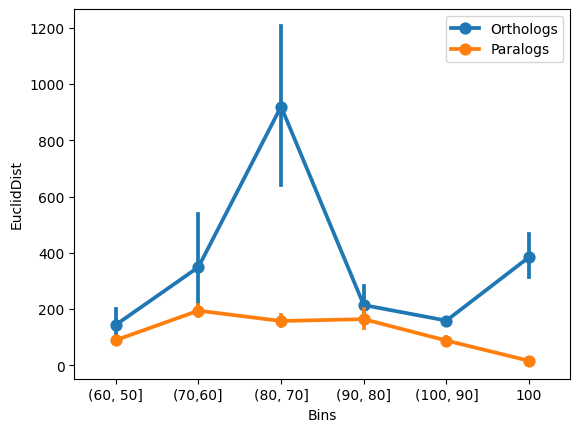

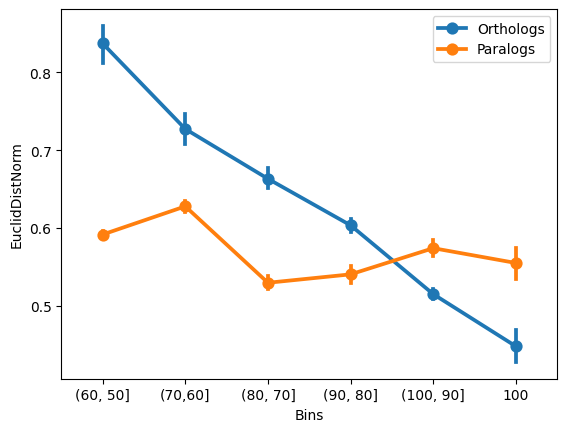

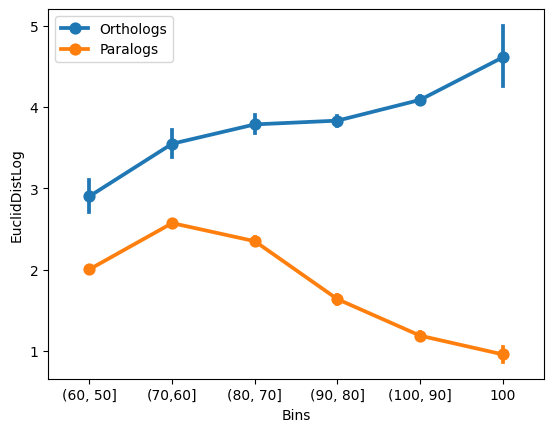

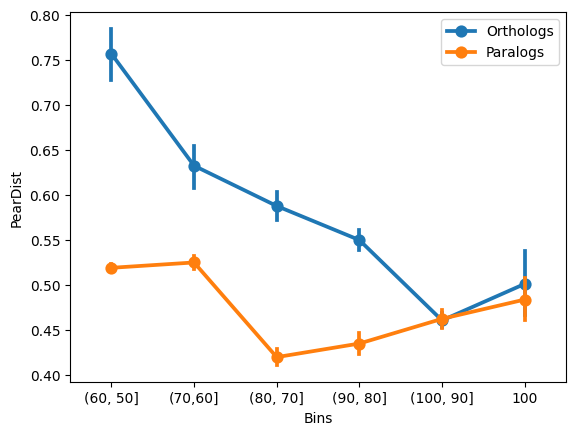

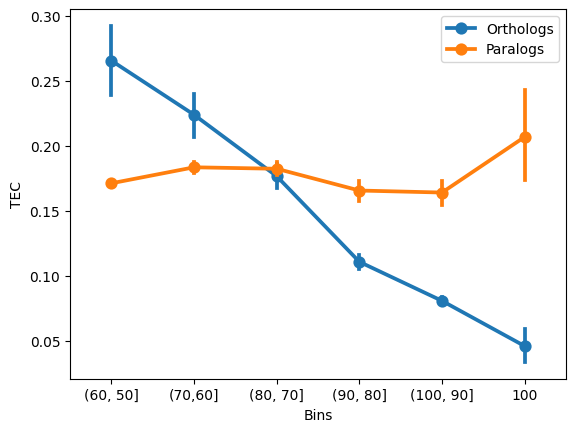

In [17]:
for distMetric in orthosVSParalogs.columns[1:6]:
    filteredDF = orthosVSParalogs.dropna(subset=[distMetric, "Bins", "Source"])
    ax = sns.pointplot(filteredDF, x="Bins", y=distMetric, hue="Source", hue_order=list(filteredDF["Source"].unique()))
    ax.get_legend().set_title("")
    plt.savefig(f"/Users/andrewhsu/Projects/McNair/plots/OrthoVsParalogProtIDDistMetric/ProtIDvs{distMetric}.png", dpi=300)
    plt.show()

In [18]:
allInParalog = allParalog[allParalog["Paralogy Type"] == "in-paralog"]
allInParalog["Source"] = "In-Paralog"

allOutParalog = allParalog[allParalog["Paralogy Type"] == "out-paralog"]
allOutParalog["Source"] = "Out-Paralog"

orthosVSInsVSOuts = pd.concat([allOrthos, allInParalog, allOutParalog], ignore_index=True)

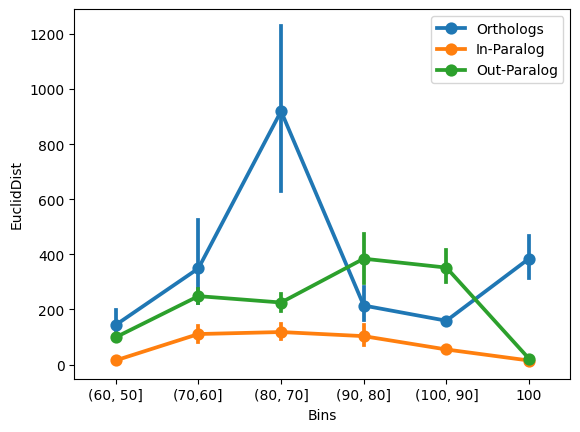

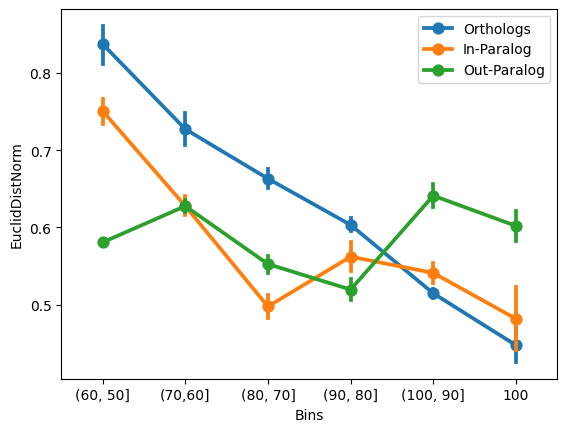

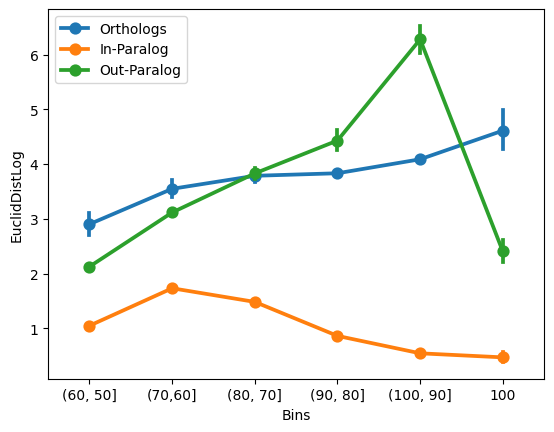

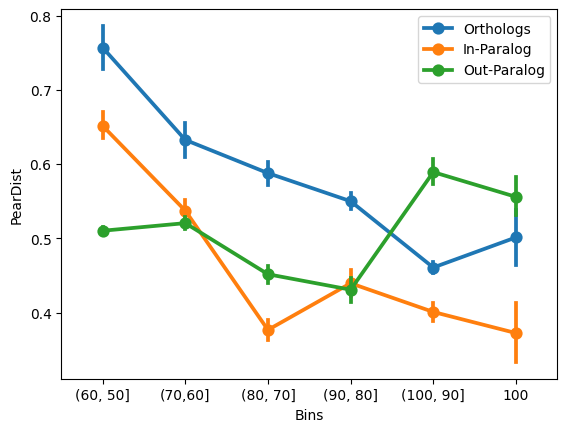

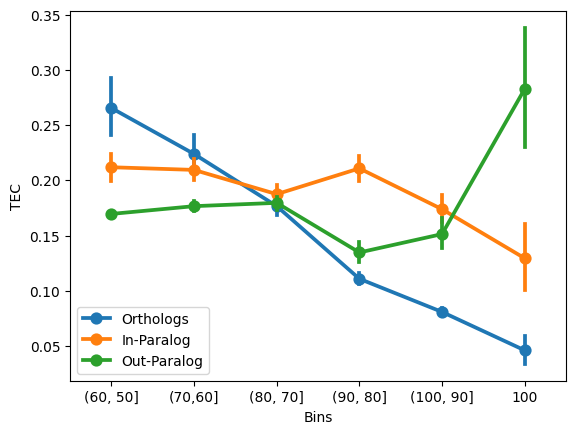

In [ ]:
for distMetric in orthosVSInsVSOuts.columns[1:-4]:
    filteredDF = orthosVSInsVSOuts.dropna(subset=[distMetric, "Bins", "Source"])
    ax = sns.pointplot(filteredDF, x="Bins", y=distMetric, hue="Source", hue_order=list(filteredDF["Source"].unique()))
    ax.get_legend().set_title("")
    plt.savefig(f"/Users/andrewhsu/Projects/McNair/plots/OrthoVsInsVsOutsProtIDDistMetric/ProtIDvs{distMetric}.png", dpi=300)
    plt.show()

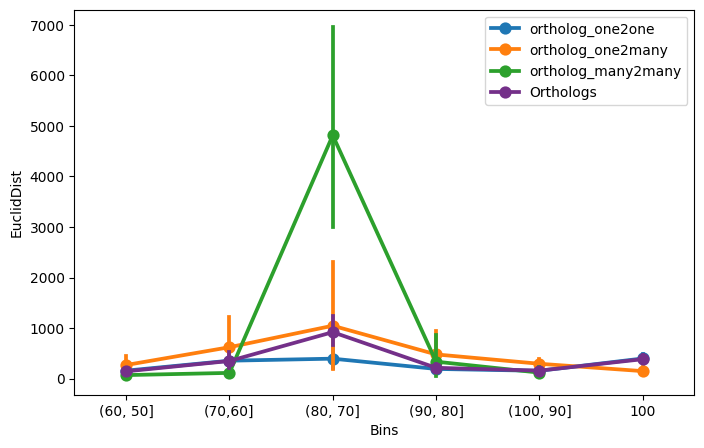

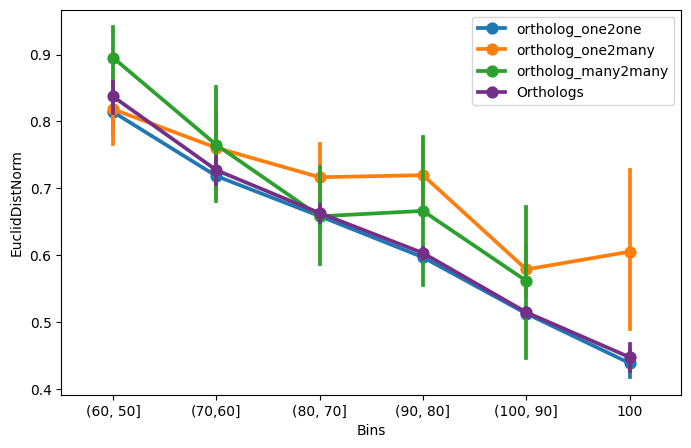

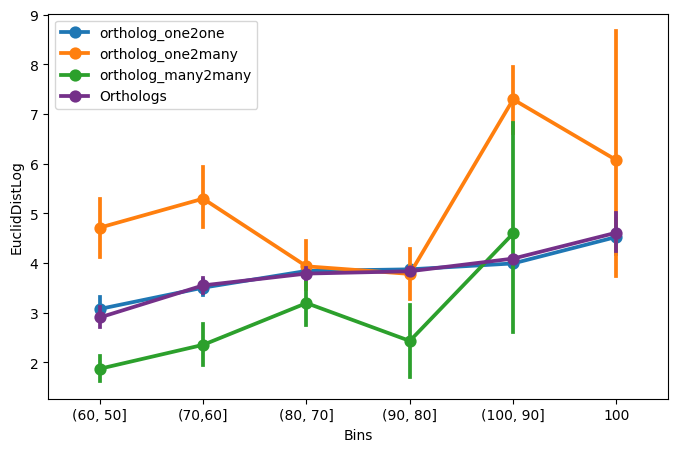

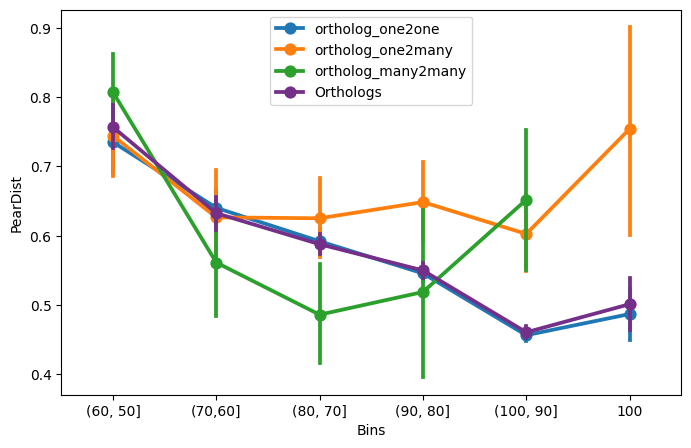

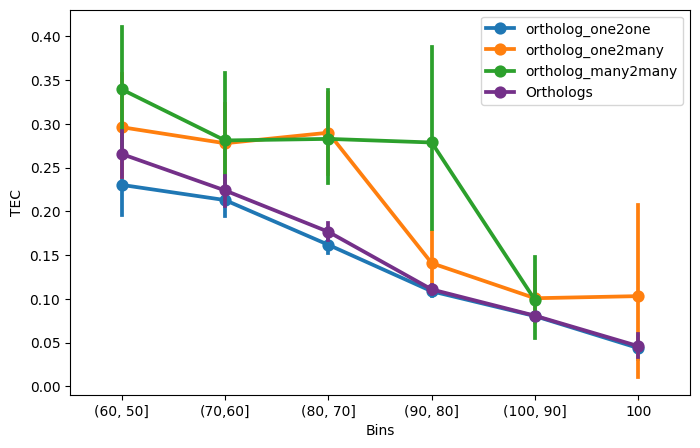

In [51]:
for distMetric in allOrthos.columns[1:6]:
    fig, ax = plt.subplots(figsize=(8, 5))
    filteredDF = allOrthos.dropna(subset=[distMetric, "Bins", "Mouse homology type", "Source"])
    sns.pointplot(filteredDF, x="Bins", y=distMetric, ax=ax, hue="Mouse homology type")
    sns.pointplot(filteredDF, x="Bins", y=distMetric, ax=ax, palette=["#743089"], hue="Source")
    ax.get_legend().set_title("")
    plt.savefig(f"/Users/andrewhsu/Projects/McNair/plots/allOrthoTypes/ProtIDvs{distMetric}.png", dpi=300)
    plt.show()